In [2]:
import pandas as pd
fourth = pd.read_parquet('cleaned_fourth_downs.parquet')

In [3]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(fourth, test_size=0.2, random_state=42)
print(f"Train rows: {len(train_df)}, Validation rows: {len(val_df)}")

Train rows: 31500, Validation rows: 7875


In [4]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['yardline_100', 'ydstogo', 'score_differential', 'game_seconds_remaining', 'qtr']

scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols]   = scaler.transform(val_df[numeric_cols])   # note: transform only, not fit

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

feature_cols = numeric_cols + ['go', 'punt', 'field_goal']

X_train = torch.tensor(train_df[feature_cols].astype('float32').values, dtype=torch.float32)
y_train = torch.tensor(train_df['epa'].astype('float32').values, dtype=torch.float32).unsqueeze(1)

X_val = torch.tensor(val_df[feature_cols].astype('float32').values, dtype=torch.float32)
y_val = torch.tensor(val_df['epa'].astype('float32').values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [6]:
import torch.nn as nn

class FourthDownNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FourthDownNet(input_dim=len(feature_cols))

In [7]:
criterion = nn.MSELoss()                                   # measures prediction error
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # adjusts the model to reduce error

In [8]:
import copy

num_epochs = 200
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None
best_epoch = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
    val_losses.append(val_loss)

    # Keep a copy of the model any time it beats its previous best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} — Train: {avg_train_loss:.4f}, Val: {val_loss:.4f}")

print(f"\nBest validation loss: {best_val_loss:.4f} at epoch {best_epoch}")

# Load the best version back into the model before saving/using it
model.load_state_dict(best_model_state)

Epoch 10/200 — Train: 2.5663, Val: 2.5759
Epoch 20/200 — Train: 2.5599, Val: 2.5730
Epoch 30/200 — Train: 2.5426, Val: 2.5913
Epoch 40/200 — Train: 2.5339, Val: 2.5891
Epoch 50/200 — Train: 2.5235, Val: 2.5932
Epoch 60/200 — Train: 2.5204, Val: 2.5835
Epoch 70/200 — Train: 2.5102, Val: 2.5845
Epoch 80/200 — Train: 2.4993, Val: 2.5905
Epoch 90/200 — Train: 2.4994, Val: 2.6035
Epoch 100/200 — Train: 2.4892, Val: 2.6119
Epoch 110/200 — Train: 2.4816, Val: 2.6101
Epoch 120/200 — Train: 2.4729, Val: 2.5972
Epoch 130/200 — Train: 2.4643, Val: 2.6083
Epoch 140/200 — Train: 2.4566, Val: 2.6088
Epoch 150/200 — Train: 2.4505, Val: 2.6125
Epoch 160/200 — Train: 2.4477, Val: 2.6416
Epoch 170/200 — Train: 2.4404, Val: 2.6361
Epoch 180/200 — Train: 2.4380, Val: 2.6178
Epoch 190/200 — Train: 2.4286, Val: 2.6223
Epoch 200/200 — Train: 2.4215, Val: 2.6552

Best validation loss: 2.5717 at epoch 13


<All keys matched successfully>

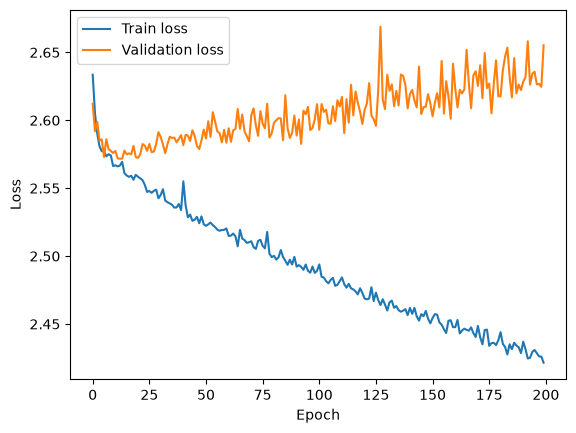

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
model.eval()
with torch.no_grad():
    val_predictions = model(X_val)
    val_loss = criterion(val_predictions, y_val)
    print(f"Validation loss: {val_loss.item():.4f}")

Validation loss: 2.5717


In [11]:
import numpy as np

def predict_all_decisions(yardline_100, ydstogo, score_differential, game_seconds_remaining, qtr):
    base = pd.DataFrame([[yardline_100, ydstogo, score_differential, game_seconds_remaining, qtr]],
                         columns=numeric_cols)
    base_scaled = scaler.transform(base)

    results = {}
    for decision, flags in [('go', [1,0,0]), ('punt', [0,1,0]), ('field_goal', [0,0,1])]:
        row = np.concatenate([base_scaled[0], flags])
        x = torch.tensor(row, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            results[decision] = model(x).item()
    return results

# Obvious "go for it" territory: 4th and 1, opponent's 3-yard line, tied, 5 min left in Q4
print("Short yardage, red zone:", predict_all_decisions(3, 1, 0, 300, 4))

# Obvious "punt" territory: 4th and 12, own 20-yard line, tied, early game
print("Long yardage, own territory:", predict_all_decisions(80, 12, 0, 3000, 1))

# Obvious "field goal" territory: 4th and 3, opponent's 15-yard line, tied, 2 min left
print("Field goal range:", predict_all_decisions(15, 3, 0, 120, 4))

Short yardage, red zone: {'go': 0.00997399166226387, 'punt': -1.1758043766021729, 'field_goal': -0.009396310895681381}
Long yardage, own territory: {'go': 0.04864262416958809, 'punt': 0.16377906501293182, 'field_goal': 0.5131852030754089}
Field goal range: {'go': 0.0038132332265377045, 'punt': -1.1246023178100586, 'field_goal': 0.04470932111144066}


In [12]:
import numpy as np

baseline_pred = np.full_like(y_val.numpy(), y_train.numpy().mean())
baseline_mse = np.mean((baseline_pred - y_val.numpy()) ** 2)
print(f"Baseline (always predict mean) MSE: {baseline_mse:.4f}")
print(f"Model validation MSE: {val_loss.item():.4f}")

Baseline (always predict mean) MSE: 2.6539
Model validation MSE: 2.5717


In [13]:
import joblib

torch.save(model.state_dict(), 'fourth_down_model.pt')
joblib.dump(scaler, 'scaler.joblib')

print("Model and scaler saved.")

Model and scaler saved.


In [14]:
def get_recommendation(row):
    results = predict_all_decisions(
        row['yardline_100'], row['ydstogo'], row['score_differential'],
        row['game_seconds_remaining'], row['qtr']
    )
    return max(results, key=results.get)

fourth['model_recommendation'] = fourth.apply(get_recommendation, axis=1)
agreement_rate = (fourth['model_recommendation'] == fourth['decision']).mean()
print(f"Coach/model agreement rate: {agreement_rate:.1%}")

Coach/model agreement rate: 38.2%


In [15]:
print(fourth['decision'].value_counts(normalize=True))
print(fourth['model_recommendation'].value_counts(normalize=True))

decision
punt          0.584838
field_goal    0.246806
go            0.168356
Name: proportion, dtype: float64
model_recommendation
field_goal    0.517410
go            0.388698
punt          0.093892
Name: proportion, dtype: float64
